# Dirichlet Process Mixture from Scratch

A finite Gaussian mixture model asks you to name the number of components $C$ before it will fit anything. The
Dirichlet process mixture does not. It places a prior over **partitions of the data** that assigns positive
probability to every number of clusters from 1 to $N$, and lets the posterior decide how many are actually
occupied. The number of clusters is not a parameter of this model — it is a property of a sample from it, and it
moves up and down while the sampler runs.

This notebook builds one from scratch in NumPy and fits it by **collapsed Gibbs sampling** over the Chinese
Restaurant Process representation, on the UCI Wine data: 178 wines, 13 chemical measurements, 3 cultivars. The
cultivar labels are held back and used only at the very end to score the result.

The companion notebook `gmm_from_scratch.ipynb` fits a finite Gaussian mixture by EM to this same dataset and is
**told** that $C = 3$. That contrast is the whole point of this method: here nothing is told, and what comes out
is a posterior distribution over the cluster count rather than a single number.

The three ingredients are:

1. **The Chinese Restaurant Process** — a prior over partitions with a simple predictive rule, which is the only
   part of the infinite-dimensional object we ever need to touch.
2. **A Normal-Inverse-Wishart prior** on each component's mean and covariance. It is conjugate to the
   multivariate Gaussian, so the component parameters can be integrated out in closed form. Only the
   assignments are ever sampled — this is what "collapsed" means.
3. **A Gibbs sweep** that removes each point from its cluster, deletes the cluster if it emptied, and redraws
   the assignment from the CRP prior times the posterior predictive likelihood, with a brand-new cluster always
   among the options.

## Imports and conventions

Everything below is NumPy and matplotlib. There is no scikit-learn, no scipy, and no probabilistic programming
library — the log-gamma function, the PCA, the Student-t density and the sampler are all written out here.

`pandas` appears only because `ucimlrepo` returns the dataset as a DataFrame.

`SEED` fixes a single `np.random.Generator` factory used by every stochastic step, so every figure and number in
this notebook reproduces exactly. `CLUSTER_COLOURS` is a fixed palette long enough for the largest cluster count
the sampler reaches.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from matplotlib.patches import Ellipse
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

SEED = 7

# the three project colours, then extras so that up to a dozen clusters stay distinguishable
CLUSTER_COLOURS = ['#2a78d6', '#eb6834', '#1baf7a',
                   '#8b4fc0', '#c9a227', '#3fb8c4',
                   '#d1467f', '#5a6b7a', '#7fbf3f',
                   '#a0522d', '#4b4b8f', '#e39ab8']

print('numpy', np.__version__)

numpy 1.26.4


## The log-gamma function, written out

The multivariate Student-t density and the Normal-Inverse-Wishart marginal likelihood both need
$\log \Gamma(x)$, and $\Gamma$ overflows for arguments well below the ones we need. Rather than import scipy,
the next cell implements the **Lanczos approximation** with $g = 7$ and 9 coefficients, which is accurate to
roughly 15 significant digits for real $x > 0$:

$$\Gamma(z+1) \approx \sqrt{2\pi}\,\left(z + g + \tfrac{1}{2}\right)^{z + 1/2} e^{-(z + g + 1/2)} \, A_g(z),
\qquad A_g(z) = c_0 + \sum_{i=1}^{8} \frac{c_i}{z + i}$$

taking logs throughout. For $x < 1/2$ the series is evaluated at $1 - x$ and mapped back with the reflection
formula $\Gamma(x)\Gamma(1-x) = \pi / \sin(\pi x)$.

`gammaln` is vectorised over NumPy arrays. `multigammaln(a, d)` is the multivariate log-gamma that the Wishart
normalising constant needs,

$$\log \Gamma_d(a) = \frac{d(d-1)}{4}\log \pi + \sum_{j=1}^{d} \log \Gamma\!\left(a + \frac{1-j}{2}\right).$$

The cell then checks `gammaln` against values known in closed form: $\Gamma(1) = 1$, $\Gamma(5) = 24$,
$\Gamma(10) = 362880$ and $\Gamma(1/2) = \sqrt{\pi}$, plus a large argument where only the log is representable.

In [2]:
_LANCZOS_G = 7.0
_LANCZOS_C = np.array([
    0.99999999999980993, 676.5203681218851, -1259.1392167224028,
    771.32342877765313, -176.61502916214059, 12.507343278686905,
    -0.13857109526572012, 9.9843695780195716e-6, 1.5056327351493116e-7])


def gammaln(x):
    x = np.asarray(x, dtype=float)
    reflect = x < 0.5
    xr = np.where(reflect, 1.0 - x, x)          # evaluate the series at 1-x when x < 1/2
    z = xr - 1.0
    s = np.full(z.shape, _LANCZOS_C[0])
    for i in range(1, _LANCZOS_C.size):
        s = s + _LANCZOS_C[i] / (z + i)
    t = z + _LANCZOS_G + 0.5
    out = 0.5 * np.log(2.0 * np.pi) + (z + 0.5) * np.log(t) - t + np.log(s)
    # reflection: log G(x) = log(pi) - log|sin(pi x)| - log G(1-x)
    xs = np.where(reflect, x, 0.5)
    out_ref = np.log(np.pi) - np.log(np.abs(np.sin(np.pi * xs))) - out
    return np.where(reflect, out_ref, out)


def multigammaln(a, d):
    j = np.arange(1, d + 1)
    return 0.25 * d * (d - 1) * np.log(np.pi) + np.sum(gammaln(a + 0.5 * (1.0 - j)))


# verify against values known exactly
checks = [('gammaln(1)   ', gammaln(1.0), 0.0),
          ('gammaln(2)   ', gammaln(2.0), 0.0),
          ('gammaln(5)   ', gammaln(5.0), np.log(24.0)),
          ('gammaln(10)  ', gammaln(10.0), np.log(362880.0)),
          ('gammaln(0.5) ', gammaln(0.5), 0.5 * np.log(np.pi)),
          ('gammaln(1.5) ', gammaln(1.5), np.log(0.5 * np.sqrt(np.pi))),
          ('gammaln(100) ', gammaln(100.0), 359.1342053695754)]

print('%-14s %18s %18s %12s' % ('argument', 'gammaln', 'exact', 'abs error'))
worst = 0.0
for name, got, want in checks:
    err = abs(float(got) - want)
    worst = max(worst, err)
    print('%-14s %18.12f %18.12f %12.2e' % (name, got, want, err))
print('\nworst absolute error: %.2e' % worst)
assert worst < 1e-9

# recurrence check on a grid: log G(x+1) - log G(x) = log x
g = np.linspace(0.05, 40.0, 500)
rec = np.max(np.abs(gammaln(g + 1.0) - gammaln(g) - np.log(g)))
print('max |log G(x+1) - log G(x) - log x| over [0.05, 40]: %.2e' % rec)
assert rec < 1e-9
print('multigammaln(3.0, 1) == gammaln(3.0):', np.isclose(multigammaln(3.0, 1), gammaln(3.0)))

argument                  gammaln              exact    abs error
gammaln(1)        -0.000000000000     0.000000000000     8.88e-16
gammaln(2)         0.000000000000     0.000000000000     0.00e+00
gammaln(5)         3.178053830348     3.178053830348     1.78e-15
gammaln(10)       12.801827480081    12.801827480081     5.33e-15
gammaln(0.5)       0.572364942925     0.572364942925     5.55e-16
gammaln(1.5)      -0.120782237635    -0.120782237635     3.19e-16
gammaln(100)     359.134205369575   359.134205369575     5.68e-14

worst absolute error: 5.68e-14
max |log G(x+1) - log G(x) - log x| over [0.05, 40]: 4.31e-14
multigammaln(3.0, 1) == gammaln(3.0): True


## The data

UCI Wine (`id=109`): 178 wines from three cultivars grown in the same region of Italy, each described by 13
continuous chemical measurements — alcohol, flavanoids, colour intensity, proline and so on. The cultivar counts
are 59 / 71 / 48.

The next cell downloads it, converts the features to a float array `X_raw` and the cultivars to `y_true` with
labels relabelled to `0, 1, 2`, and standardises every column to zero mean and unit variance to give `X_std`.
Standardising matters here: proline runs in the hundreds while hue is around 1, and an isotropic
Normal-Inverse-Wishart prior placed on unstandardised data would be describing a prior belief that no one holds.

`y_true` is not used again until the scoring section at the end. The sampler never sees it.

In [3]:
wine = fetch_ucirepo(id=109)

feature_names = list(wine.data.features.columns)
X_raw = wine.data.features.to_numpy(dtype=float)
y_raw = wine.data.targets.to_numpy().ravel().astype(int)
y_true = np.searchsorted(np.unique(y_raw), y_raw)          # cultivars 1,2,3 -> 0,1,2

N_all, D_raw = X_raw.shape
X_std = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

print('X_raw', X_raw.shape, '  missing values:', int(np.isnan(X_raw).sum()))
print('features:', feature_names)
for c in range(3):
    print('  cultivar %d: %3d wines' % (c + 1, np.sum(y_true == c)))
print('\nstandardised column means (max abs): %.2e' % np.max(np.abs(X_std.mean(axis=0))))
print('standardised column sds   (max dev): %.2e' % np.max(np.abs(X_std.std(axis=0) - 1.0)))

X_raw (178, 13)   missing values: 0
features: ['Alcohol', 'Malicacid', 'Ash', 'Alcalinity_of_ash', 'Magnesium', 'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', 'Proanthocyanins', 'Color_intensity', 'Hue', '0D280_0D315_of_diluted_wines', 'Proline']
  cultivar 1:  59 wines
  cultivar 2:  71 wines
  cultivar 3:  48 wines

standardised column means (max abs): 8.38e-16
standardised column sds   (max dev): 2.22e-16


## Reducing to four principal components, and why

The sampler is run on the **first four principal components**, not on all 13 standardised features. This is a
deliberate choice and it changes the answer, so it needs stating plainly.

A Normal-Inverse-Wishart posterior in $D = 13$ dimensions has to support a $13 \times 13$ covariance from the
points assigned to one cluster. The degrees-of-freedom parameter must satisfy $\nu_0 > D + 1$ just for the prior
mean to exist, and a cluster of 15 points is then estimating 91 covariance entries. The posterior predictive
becomes so diffuse that the likelihood term barely discriminates between clusters, the $\alpha$ term dominates,
and the sampler chases directions along which a handful of points happen to line up. Cutting to four dimensions
puts roughly 45 points per cluster against 10 covariance entries.

`pca` is five lines: centre the matrix, take the SVD, and the scores are $U_k \Sigma_k$ where the columns of $V$
are the loading vectors. The column variances of the scores are the eigenvalues of the covariance matrix.

Four components keep **73.6%** of the standardised variance. The cost is real — the discarded 26% contains
information the cultivars do differ on — and the effect of the choice is shown directly: the next cell also runs
the finished sampler at $D = 2, 3, 4, 5$ and prints the posterior cluster count for each, so the dependence is
visible rather than hidden. That comparison appears after the sampler is defined; for now the cell computes the
scores and plots the spectrum.

**Figure 1** shows the explained-variance spectrum with the four retained components marked, and the wines drawn
on the first two components coloured by cultivar. The cultivars are visibly three clouds, but two of them touch.

scores Z_all (178, 4)
explained variance by component: [0.362  0.1921 0.1112 0.0707 0.0656 0.0494 0.0424 0.0268]
cumulative:                      [0.362  0.5541 0.6653 0.736  0.8016 0.851  0.8934 0.9202]
retained with 4 components: 73.6%
score column variances: [4.706 2.497 1.446 0.919]


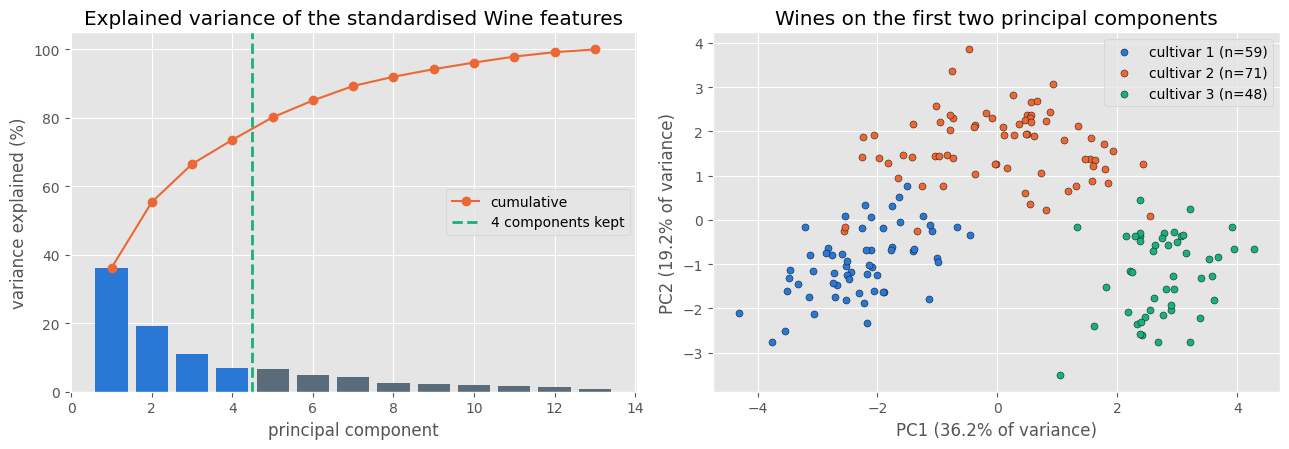

In [4]:
def pca(X, k):
    Xc = X - X.mean(axis=0)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    return U[:, :k] * S[:k], Vt[:k], S ** 2 / np.sum(S ** 2)


D_PCA = 4
Z_all, loadings, explained = pca(X_std, D_PCA)
N, D = Z_all.shape

print('scores Z_all', Z_all.shape)
print('explained variance by component:', np.round(explained[:8], 4))
print('cumulative:                     ', np.round(np.cumsum(explained[:8]), 4))
print('retained with %d components: %.1f%%' % (D_PCA, 100 * np.cumsum(explained)[D_PCA - 1]))
print('score column variances:', np.round(Z_all.var(axis=0), 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

ncomp = np.arange(1, D_raw + 1)
ax[0].bar(ncomp, explained * 100, color=['#2a78d6'] * D_PCA + ['#5a6b7a'] * (D_raw - D_PCA))
ax[0].plot(ncomp, np.cumsum(explained) * 100, 'o-', color='#eb6834', label='cumulative')
ax[0].axvline(D_PCA + 0.5, color='#1baf7a', lw=2, ls='--', label='%d components kept' % D_PCA)
ax[0].set_title('Explained variance of the standardised Wine features')
ax[0].set_xlabel('principal component')
ax[0].set_ylabel('variance explained (%)')
ax[0].legend()

for c in range(3):
    m = y_true == c
    ax[1].scatter(Z_all[m, 0], Z_all[m, 1], s=26, color=CLUSTER_COLOURS[c],
                  edgecolor='k', linewidth=0.3, label='cultivar %d (n=%d)' % (c + 1, m.sum()))
ax[1].set_title('Wines on the first two principal components')
ax[1].set_xlabel('PC1 (%.1f%% of variance)' % (100 * explained[0]))
ax[1].set_ylabel('PC2 (%.1f%% of variance)' % (100 * explained[1]))
ax[1].legend()

plt.tight_layout()
plt.show()

## The Chinese Restaurant Process

This is the predictive rule that does all the work. Customers enter a restaurant with infinitely many tables.
The first sits anywhere. Customer $i$, given where everyone else sits, joins an occupied table with probability
proportional to how many people are already there, and starts a new table with probability proportional to
$\alpha$:

$$P(z_i = c \mid \mathbf{z}_{-i}) = \frac{n_{-i,c}}{N - 1 + \alpha} \quad \text{for existing } c,
\qquad P(z_i = \text{new}) = \frac{\alpha}{N - 1 + \alpha}$$

where $n_{-i,c}$ counts the points assigned to cluster $c$ excluding point $i$. Two properties follow directly:

- **Rich get richer.** The probability of joining a table is linear in its occupancy, so large clusters grow
  faster than small ones and the partition concentrates on a few big tables plus a tail of small ones. The
  induced distribution of table sizes is a power law, not anything uniform.
- **A new table is always possible.** The $\alpha$ term never vanishes, at any point, at any stage of sampling.
  The number of clusters is unbounded *a priori* — this is precisely what makes the model **nonparametric**. The
  data, through the likelihood, is what stops it from growing without limit.

The rule is exchangeable: the probability of a partition does not depend on the order in which customers
arrived. That is what licenses the Gibbs sweep later, where every point in turn is treated as if it were the
*last* customer to walk in.

The joint prior over an assignment vector, with $K$ occupied tables of sizes $n_1, \dots, n_K$, is

$$P(\mathbf{z} \mid \alpha) = \alpha^{K} \, \frac{\Gamma(\alpha)}{\Gamma(N + \alpha)} \prod_{c=1}^{K} \Gamma(n_c).$$

`crp_sample` seats `n` customers one at a time by exactly this rule and returns the table sizes.
`crp_log_prior` evaluates the expression above. **Figure 2** runs `crp_sample` for several $\alpha$ at
$N = 400$: the left panel shows the table-size distributions on log axes, the right shows how the number of
occupied tables grows with the number of customers seated. This is the process on its own, with no data
involved.

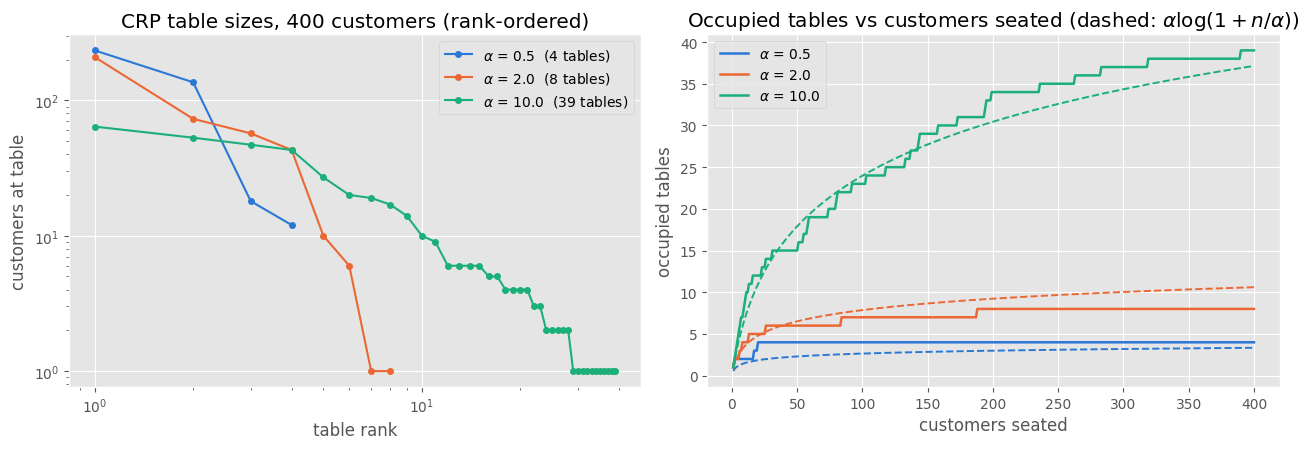

alpha   0.5  tables   9  largest table 100  singletons   1
alpha   2.0  tables   4  largest table 376  singletons   0
alpha  10.0  tables  38  largest table  52  singletons   8


In [5]:
def crp_sample(n, alpha, rng):
    counts = []
    growth = np.empty(n, dtype=int)
    for i in range(n):
        w = np.array(counts + [alpha], dtype=float)
        k = rng.choice(len(w), p=w / w.sum())
        if k == len(counts):
            counts.append(0)
        counts[k] += 1
        growth[i] = len(counts)
    return np.array(counts), growth


def crp_log_prior(counts, alpha):
    counts = np.asarray(counts, dtype=float)
    n = counts.sum()
    return (counts.size * np.log(alpha) + np.sum(gammaln(counts))
            + gammaln(alpha) - gammaln(n + alpha))


rng = np.random.default_rng(SEED)
n_cust = 400
alphas_demo = [0.5, 2.0, 10.0]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for j, a in enumerate(alphas_demo):
    sizes, growth = crp_sample(n_cust, a, rng)
    s = np.sort(sizes)[::-1]
    ax[0].plot(np.arange(1, s.size + 1), s, 'o-', ms=4, color=CLUSTER_COLOURS[j],
               label=r'$\alpha$ = %.1f  (%d tables)' % (a, s.size))
    ax[1].plot(np.arange(1, n_cust + 1), growth, color=CLUSTER_COLOURS[j], lw=1.8,
               label=r'$\alpha$ = %.1f' % a)
    ax[1].plot(np.arange(1, n_cust + 1),
               a * np.log1p(np.arange(1, n_cust + 1) / a),
               color=CLUSTER_COLOURS[j], lw=1.4, ls='--')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('CRP table sizes, %d customers (rank-ordered)' % n_cust)
ax[0].set_xlabel('table rank')
ax[0].set_ylabel('customers at table')
ax[0].legend()

ax[1].set_title(r'Occupied tables vs customers seated (dashed: $\alpha\log(1+n/\alpha)$)')
ax[1].set_xlabel('customers seated')
ax[1].set_ylabel('occupied tables')
ax[1].legend()

plt.tight_layout()
plt.show()

for a in alphas_demo:
    sizes, _ = crp_sample(n_cust, a, rng)
    print('alpha %5.1f  tables %3d  largest table %3d  singletons %3d'
          % (a, sizes.size, sizes.max(), int(np.sum(sizes == 1))))

## Stick-breaking: the same object seen from the other side

The CRP describes the partition without ever writing down the mixing weights. The **stick-breaking**
construction writes them down explicitly. Take a stick of length 1 and repeatedly break off a Beta-distributed
fraction of what remains:

$$\beta_k \sim \text{Beta}(1, \alpha), \qquad \pi_k = \beta_k \prod_{j<k}(1 - \beta_j)$$

The weights $\pi_1, \pi_2, \dots$ sum to 1 almost surely and decay geometrically on average, since
$E[\beta_k] = 1/(1+\alpha)$ leaves a fraction $\alpha/(1+\alpha)$ of the stick each time. Draw component
parameters $\theta_k \sim G_0$ independently from the base measure and the random discrete measure

$$G = \sum_{k=1}^{\infty} \pi_k \delta_{\theta_k} \sim \text{DP}(\alpha, G_0)$$

is a draw from the Dirichlet process. Drawing $\theta \sim G$ for each data point and integrating out $G$ gives
back exactly the CRP seating rule — the two constructions describe one object. Large $\alpha$ breaks small
pieces off the stick and spreads mass over many components; small $\alpha$ takes most of the stick in the first
few breaks.

A useful consequence, and one this notebook checks twice, is the expected number of **occupied** components
after $N$ draws:

$$E[K] \approx \alpha \log\!\left(1 + \frac{N}{\alpha}\right)$$

The growth is **logarithmic** in $N$: doubling the data adds a roughly constant number of clusters rather than
doubling them. This is a prior statement — it says nothing about the data yet.

The next cell draws stick-breaking weights at three $\alpha$ values and prints how much of the stick the first
few components take, then checks $E[K] \approx \alpha \log(1 + N/\alpha)$ empirically by averaging `crp_sample`
over 200 restaurants at $N = 178$, the size of the Wine data.

In [6]:
def stick_breaking(alpha, k, rng):
    beta = rng.beta(1.0, alpha, size=k)
    remaining = np.concatenate([[1.0], np.cumprod(1.0 - beta)[:-1]])
    return beta * remaining


rng = np.random.default_rng(SEED + 1)
print('stick-breaking weights, first 8 components')
for a in [0.5, 2.0, 10.0]:
    w = stick_breaking(a, 60, rng)
    print('  alpha %5.1f  ' % a, np.round(w[:8], 3), '  first 8 hold %.1f%% of the stick'
          % (100 * w[:8].sum()))

print('\nE[K] check by simulation, N = %d, 200 restaurants each' % N)
print('%8s %14s %14s %10s' % ('alpha', 'simulated E[K]', 'a*log(1+N/a)', 'sd'))
for a in [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]:
    ks = np.array([crp_sample(N, a, rng)[0].size for _ in range(200)], dtype=float)
    print('%8.2f %14.2f %14.2f %10.2f' % (a, ks.mean(), a * np.log1p(N / a), ks.std()))

stick-breaking weights, first 8 components
  alpha   0.5   [0.339 0.502 0.051 0.085 0.019 0.003 0.    0.   ]   first 8 hold 100.0% of the stick
  alpha   2.0   [0.172 0.191 0.142 0.041 0.353 0.068 0.006 0.007]   first 8 hold 98.0% of the stick
  alpha  10.0   [0.033 0.083 0.013 0.094 0.194 0.149 0.048 0.05 ]   first 8 hold 66.4% of the stick

E[K] check by simulation, N = 178, 200 restaurants each
   alpha simulated E[K]   a*log(1+N/a)         sd


    0.10           1.57           0.75       0.75


    0.30           2.77           1.92       1.33


    1.00           5.61           5.19       1.89


    3.00          12.98          12.30       3.02


   10.00          30.23          29.34       4.00


   30.00          58.19          58.09       5.24


## The Normal-Inverse-Wishart prior and the Student-t predictive

Each component is a multivariate Gaussian $\mathcal{N}(\boldsymbol\mu, \Sigma)$ with both parameters unknown.
The base measure $G_0$ is the conjugate Normal-Inverse-Wishart,

$$\Sigma \sim \mathcal{W}^{-1}(\Lambda_0, \nu_0), \qquad
\boldsymbol\mu \mid \Sigma \sim \mathcal{N}\!\left(\boldsymbol\mu_0, \tfrac{1}{\kappa_0}\Sigma\right),$$

with four hyperparameters: a prior mean $\boldsymbol\mu_0$, a strength $\kappa_0$ saying how many pseudo-
observations that mean is worth, a scale matrix $\Lambda_0$, and degrees of freedom $\nu_0 > D + 1$ controlling
how tightly $\Sigma$ concentrates on $\Lambda_0 / (\nu_0 - D - 1)$.

Given $n$ points in a cluster with mean $\bar{\mathbf{x}}$ and scatter
$S = \sum_i (\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^{\top}$, the posterior is
Normal-Inverse-Wishart again with

$$\kappa_n = \kappa_0 + n, \qquad \nu_n = \nu_0 + n, \qquad
\boldsymbol\mu_n = \frac{\kappa_0 \boldsymbol\mu_0 + n \bar{\mathbf{x}}}{\kappa_n}, \qquad
\Lambda_n = \Lambda_0 + S + \frac{\kappa_0 n}{\kappa_n}
(\bar{\mathbf{x}} - \boldsymbol\mu_0)(\bar{\mathbf{x}} - \boldsymbol\mu_0)^{\top}.$$

Conjugacy is the entire reason this model is tractable, because it lets both $\boldsymbol\mu$ and $\Sigma$ be
**integrated out**. The posterior predictive for a new point is not a Gaussian but a multivariate Student-t:

$$p(\mathbf{x} \mid \mathbf{X}_c) = t_{\nu_n - D + 1}\!\left(\boldsymbol\mu_n,\
\frac{\Lambda_n(\kappa_n+1)}{\kappa_n(\nu_n - D + 1)}\right)$$

with density

$$t_{\nu}(\mathbf{x} \mid \mathbf{m}, \Sigma) =
\frac{\Gamma\!\left(\frac{\nu + D}{2}\right)}{\Gamma\!\left(\frac{\nu}{2}\right)(\nu\pi)^{D/2}|\Sigma|^{1/2}}
\left[1 + \frac{1}{\nu}(\mathbf{x}-\mathbf{m})^{\top}\Sigma^{-1}(\mathbf{x}-\mathbf{m})\right]^{-\frac{\nu+D}{2}}.$$

The heavy tails are not a modelling flourish; they are the arithmetic consequence of not knowing $\Sigma$. A
cluster of four points genuinely does not know its own spread, and the predictive correctly refuses to be
confident about how far a fifth point might fall. As $n$ grows, $\nu_n$ grows with it and the t collapses onto
the Gaussian. This is why the model does not shatter into singletons: a one-point cluster has an extremely broad
predictive and therefore assigns low density to any specific location, so it is a poor place for a second point
to go unless it is genuinely far from everything else.

The marginal likelihood of an entire cluster, also in closed form and needed for the log-posterior trace, is

$$p(\mathbf{X}_c) = \pi^{-nD/2} \frac{\kappa_0^{D/2}}{\kappa_n^{D/2}}
\frac{|\Lambda_0|^{\nu_0/2}}{|\Lambda_n|^{\nu_n/2}} \frac{\Gamma_D(\nu_n/2)}{\Gamma_D(\nu_0/2)}.$$

The next cell implements all three: `niw_posterior` from cached sufficient statistics, `log_student_t` from a
Cholesky factor, and `niw_log_marginal`. Sufficient statistics are held as the count $n$, the sum
$\sum_i \mathbf{x}_i$ and the outer-product sum $\sum_i \mathbf{x}_i \mathbf{x}_i^{\top}$, which is what makes
adding and removing a single point $O(D^2)$ instead of $O(nD)$. The cell finishes by checking the Student-t
density integrates to 1 on a grid in 2-D and that it approaches the Gaussian as $\nu$ grows.

In [7]:
def niw_posterior(n, xsum, xxsum, mu0, kappa0, nu0, Lam0):
    kn = kappa0 + n
    nun = nu0 + n
    mun = (kappa0 * mu0 + xsum) / kn
    # Lam_n = Lam0 + sum xx' + kappa0 mu0 mu0' - kn mun mun'   (algebraically equal to the scatter form)
    Lamn = Lam0 + xxsum + kappa0 * np.outer(mu0, mu0) - kn * np.outer(mun, mun)
    Lamn = 0.5 * (Lamn + Lamn.T)                      # kill accumulated asymmetry
    return kn, nun, mun, Lamn


def log_student_t(x, mean, scale, dof):
    d = mean.size
    L = np.linalg.cholesky(scale)
    v = np.linalg.solve(L, x - mean)
    quad = float(np.dot(v, v))
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    return float(gammaln(0.5 * (dof + d)) - gammaln(0.5 * dof)
                 - 0.5 * d * np.log(dof * np.pi) - 0.5 * logdet
                 - 0.5 * (dof + d) * np.log1p(quad / dof))


def niw_log_predictive(x, n, xsum, xxsum, mu0, kappa0, nu0, Lam0):
    d = mu0.size
    kn, nun, mun, Lamn = niw_posterior(n, xsum, xxsum, mu0, kappa0, nu0, Lam0)
    dof = nun - d + 1.0
    scale = Lamn * (kn + 1.0) / (kn * dof)
    return log_student_t(x, mun, scale, dof)


def niw_log_marginal(n, xsum, xxsum, mu0, kappa0, nu0, Lam0):
    d = mu0.size
    kn, nun, mun, Lamn = niw_posterior(n, xsum, xxsum, mu0, kappa0, nu0, Lam0)
    _, ld0 = np.linalg.slogdet(Lam0)
    _, ldn = np.linalg.slogdet(Lamn)
    return (-0.5 * n * d * np.log(np.pi) + 0.5 * d * (np.log(kappa0) - np.log(kn))
            + 0.5 * nu0 * ld0 - 0.5 * nun * ldn
            + multigammaln(0.5 * nun, d) - multigammaln(0.5 * nu0, d))


# the Student-t density integrates to 1, and tends to the Gaussian as dof grows
m2 = np.zeros(2)
S2 = np.array([[1.0, 0.4], [0.4, 0.7]])
gx = np.linspace(-14, 14, 601)
step = gx[1] - gx[0]
for dof in [3.0, 30.0, 300.0]:
    G1, G2 = np.meshgrid(gx, gx, indexing='ij')
    pts = np.stack([G1.ravel(), G2.ravel()], axis=1)
    L = np.linalg.cholesky(S2)
    V = np.linalg.solve(L, (pts - m2).T)
    quad = np.sum(V * V, axis=0)
    logdet = 2.0 * np.sum(np.log(np.diag(L)))
    lp = (gammaln(0.5 * (dof + 2)) - gammaln(0.5 * dof) - np.log(dof * np.pi)
          - 0.5 * logdet - 0.5 * (dof + 2) * np.log1p(quad / dof))
    print('dof %6.0f   grid integral of t density = %.6f   log t(0) = %+.6f   log N(0) = %+.6f'
          % (dof, np.exp(lp).sum() * step * step, lp.reshape(G1.shape)[300, 300],
             -np.log(2 * np.pi) - 0.5 * logdet))

dof      3   grid integral of t density = 0.998946   log t(0) = -1.529784   log N(0) = -1.529784
dof     30   grid integral of t density = 1.000000   log t(0) = -1.529784   log N(0) = -1.529784


dof    300   grid integral of t density = 1.000000   log t(0) = -1.529784   log N(0) = -1.529784


## The collapsed Gibbs update

Put the two pieces together. Because the component parameters are integrated out, the state of the sampler is
**only** the assignment vector $\mathbf{z}$. To resample $z_i$, remove point $i$ from its current cluster,
delete the cluster if that emptied it, and draw

$$P(z_i = c \mid \mathbf{z}_{-i}, \mathbf{X}) \;\propto\;
\underbrace{n_{-i,c}}_{\text{CRP prior}} \cdot
\underbrace{t_{\nu_n - D + 1}\!\left(\mathbf{x}_i \mid \boldsymbol\mu_n, \tfrac{\Lambda_n(\kappa_n+1)}
{\kappa_n(\nu_n - D + 1)}\right)}_{\text{predictive under cluster } c \text{ without } i}$$

for each occupied cluster $c$, and

$$P(z_i = \text{new} \mid \mathbf{z}_{-i}, \mathbf{X}) \;\propto\;
\alpha \cdot t_{\nu_0 - D + 1}\!\left(\mathbf{x}_i \mid \boldsymbol\mu_0,
\tfrac{\Lambda_0(\kappa_0+1)}{\kappa_0(\nu_0 - D + 1)}\right)$$

for a fresh cluster, where the predictive is taken under the prior alone. Normalise over the $K + 1$ options and
sample. The $N - 1 + \alpha$ denominator of the CRP is a constant across the options and cancels.

**What "collapsed" means and why it mixes better.** An uncollapsed Gibbs sampler would alternate between drawing
$\mathbf{z}$ given every $(\boldsymbol\mu_c, \Sigma_c)$ and drawing every $(\boldsymbol\mu_c, \Sigma_c)$ given
$\mathbf{z}$. Those two blocks are strongly dependent: a cluster's parameters are pinned by its current members,
so points cannot move far without the parameters moving first, and the parameters will not move until the points
do. The chain crawls. Marginalising $(\boldsymbol\mu_c, \Sigma_c)$ out analytically removes that coupling
entirely — the parameters are never instantiated, so there is nothing for the assignments to be stuck against,
and by the Rao-Blackwell theorem the resulting estimator also has lower variance. The cost is that the update is
sequential: cluster statistics change after every single point, so a sweep cannot be vectorised over points.

The next cell defines `Dirichlet_Process_Mixture`. Its state is `z` plus, for each cluster, the three sufficient
statistics `n_k`, `sum_k`, `outer_k`. `_default_prior` sets $\boldsymbol\mu_0$ to the data mean, $\nu_0 = D + 2$
(the smallest value for which the prior mean of $\Sigma$ exists), $\kappa_0 = 0.05$ (a deliberately weak belief
about the location), and $\Lambda_0 = (\nu_0 - D - 1)\,\text{diag}(\text{var}(\mathbf{X}))$, so that a component
is expected *a priori* to be about as broad as the whole dataset. That last choice matters and is revisited at
the end. `fit` runs `sweeps` full passes; `_rebuild_stats` recomputes the sufficient statistics from scratch at
the start of every sweep so that repeated add/remove arithmetic cannot drift. `log_joint` evaluates
$\log P(\mathbf{z} \mid \alpha) + \sum_c \log p(\mathbf{X}_c)$, the collapsed log-posterior up to a constant.

In [8]:
class Dirichlet_Process_Mixture:

    def __init__(self, alpha=1.0, kappa0=0.05, nu0=None, mu0=None, Lam0=None, seed=SEED):
        self.alpha = alpha
        self.kappa0 = kappa0
        self.nu0 = nu0
        self.mu0 = mu0
        self.Lam0 = Lam0
        self.seed = seed

    def _default_prior(self, X):
        n, d = X.shape
        self.d = d
        if self.mu0 is None:
            self.mu0 = X.mean(axis=0)
        if self.nu0 is None:
            self.nu0 = float(d + 2)              # smallest dof with a finite prior mean for Sigma
        if self.Lam0 is None:
            # E[Sigma] = Lam0 / (nu0 - d - 1) = diag(var(X)): a component is a priori as broad as the data
            self.Lam0 = (self.nu0 - d - 1.0) * np.diag(X.var(axis=0))

    def _rebuild_stats(self, X):
        k = int(self.z.max()) + 1
        self.n_k = [0] * k
        self.sum_k = [np.zeros(self.d) for _ in range(k)]
        self.outer_k = [np.zeros((self.d, self.d)) for _ in range(k)]
        for c in range(k):
            m = self.z == c
            self.n_k[c] = int(m.sum())
            self.sum_k[c] = X[m].sum(axis=0)
            self.outer_k[c] = X[m].T @ X[m]

    def _log_pred(self, x, c):
        if c is None:                            # a brand-new cluster: predictive under the prior alone
            return niw_log_predictive(x, 0, np.zeros(self.d), np.zeros((self.d, self.d)),
                                      self.mu0, self.kappa0, self.nu0, self.Lam0)
        return niw_log_predictive(x, self.n_k[c], self.sum_k[c], self.outer_k[c],
                                  self.mu0, self.kappa0, self.nu0, self.Lam0)

    def log_joint(self):
        ll = crp_log_prior(self.n_k, self.alpha)
        for c in range(len(self.n_k)):
            ll += niw_log_marginal(self.n_k[c], self.sum_k[c], self.outer_k[c],
                                   self.mu0, self.kappa0, self.nu0, self.Lam0)
        return ll

    def fit(self, X, sweeps=400, init_k=1, verbose=0):
        rng = np.random.default_rng(self.seed)
        self._default_prior(X)
        n = X.shape[0]

        self.z = rng.integers(0, init_k, size=n)
        self.z = np.searchsorted(np.unique(self.z), self.z)
        self._rebuild_stats(X)

        self.k_trace = np.empty(sweeps, dtype=int)
        self.lj_trace = np.empty(sweeps)
        self.z_trace = np.empty((sweeps, n), dtype=int)

        t0 = time.time()
        for it in range(sweeps):
            self._rebuild_stats(X)               # guard against drift from repeated add/remove
            for i in rng.permutation(n):
                x = X[i]
                c = self.z[i]

                # remove point i from its cluster
                self.n_k[c] -= 1
                self.sum_k[c] -= x
                self.outer_k[c] -= np.outer(x, x)
                if self.n_k[c] == 0:             # cluster emptied: delete it and relabel
                    del self.n_k[c], self.sum_k[c], self.outer_k[c]
                    self.z[self.z > c] -= 1

                k = len(self.n_k)
                logp = np.empty(k + 1)
                for cc in range(k):
                    logp[cc] = np.log(self.n_k[cc]) + self._log_pred(x, cc)
                logp[k] = np.log(self.alpha) + self._log_pred(x, None)

                logp -= logp.max()
                p = np.exp(logp)
                p /= p.sum()
                new_c = int(rng.choice(k + 1, p=p))

                if new_c == k:                   # a brand-new cluster
                    self.n_k.append(0)
                    self.sum_k.append(np.zeros(self.d))
                    self.outer_k.append(np.zeros((self.d, self.d)))
                self.n_k[new_c] += 1
                self.sum_k[new_c] += x
                self.outer_k[new_c] += np.outer(x, x)
                self.z[i] = new_c

            self.k_trace[it] = len(self.n_k)
            self.lj_trace[it] = self.log_joint()
            self.z_trace[it] = self.z
            if verbose and (it % verbose == 0 or it == sweeps - 1):
                print('  sweep %4d   K = %2d   log joint = %10.1f   %5.1fs'
                      % (it, self.k_trace[it], self.lj_trace[it], time.time() - t0), flush=True)

        self.fit_seconds = time.time() - t0
        return self

    def posterior_k(self, burn_in):
        return self.k_trace[burn_in:]

    def cluster_moments(self, X, z):
        # posterior mean mu and Sigma per cluster, used only for drawing ellipses
        out = []
        for c in range(int(z.max()) + 1):
            m = z == c
            xs = X[m]
            kn, nun, mun, Lamn = niw_posterior(int(m.sum()), xs.sum(axis=0), xs.T @ xs,
                                               self.mu0, self.kappa0, self.nu0, self.Lam0)
            out.append((mun, Lamn / (nun - self.d - 1.0), int(m.sum())))
        return out

## Running the sampler

`model` is fitted with $\alpha = 1$ for 500 sweeps, started from a single cluster containing all 178 wines. The
first 150 sweeps are discarded as burn-in; the cluster count is read from the remaining 350.

Starting from $K = 1$ is deliberate. It means every cluster the sampler ends up with was created by the
`z_i = new` branch of the update, against the prior's preference, because the predictive likelihood paid for it.
Nothing about the count is seeded.

In [9]:
Z = Z_all
ALPHA = 1.0
SWEEPS = 500
BURN = 150

t_start = time.time()
model = Dirichlet_Process_Mixture(alpha=ALPHA, seed=SEED).fit(Z, sweeps=SWEEPS, init_k=1, verbose=50)
print('\nfit finished in %.1f s (%.1f ms per sweep)'
      % (model.fit_seconds, 1000 * model.fit_seconds / SWEEPS))

k_post = model.posterior_k(BURN)
k_vals, k_counts = np.unique(k_post, return_counts=True)
k_mode = int(k_vals[np.argmax(k_counts)])

print('\nposterior over the number of clusters (after %d burn-in sweeps):' % BURN)
for v, c in zip(k_vals, k_counts):
    print('  K = %2d : %5.3f  %s' % (v, c / k_post.size, '#' * int(round(60 * c / k_post.size))))
print('\nposterior mode K = %d,  mean %.2f,  range %d-%d,  true cultivars 3'
      % (k_mode, k_post.mean(), k_post.min(), k_post.max()))

  sweep    0   K =  2   log joint =    -1304.3     0.1s


  sweep   50   K =  5   log joint =    -1210.2    12.6s


  sweep  100   K =  7   log joint =    -1262.1    27.1s


  sweep  150   K =  7   log joint =    -1224.4    43.4s


  sweep  200   K =  7   log joint =    -1219.7    61.3s


...

  sweep  350   K =  7   log joint =    -1232.4   115.0s


  sweep  400   K =  7   log joint =    -1227.1   132.9s


  sweep  450   K =  7   log joint =    -1210.8   149.1s


  sweep  499   K =  7   log joint =    -1257.1   167.8s



fit finished in 167.8 s (335.7 ms per sweep)

posterior over the number of clusters (after 150 burn-in sweeps):
  K =  5 : 0.040  ##
  K =  6 : 0.157  #########
  K =  7 : 0.426  ##########################
  K =  8 : 0.271  ################
  K =  9 : 0.094  ######
  K = 10 : 0.011  #

posterior mode K = 7,  mean 7.26,  range 5-10,  true cultivars 3


## Figure 3: the number of clusters per sweep

This is the signature figure of the method. The line is the number of occupied clusters at the end of each Gibbs
sweep. It is not a parameter being optimised towards a target — it is a sampled quantity that moves up when the
likelihood pays for a new component and down when a cluster empties and is deleted.

The trace should climb quickly out of the $K = 1$ initialisation and then wander within a band. That band is the
posterior, and its width is the honest statement of how well determined the cluster count is by 178 wines under
this prior. A single number would hide it.

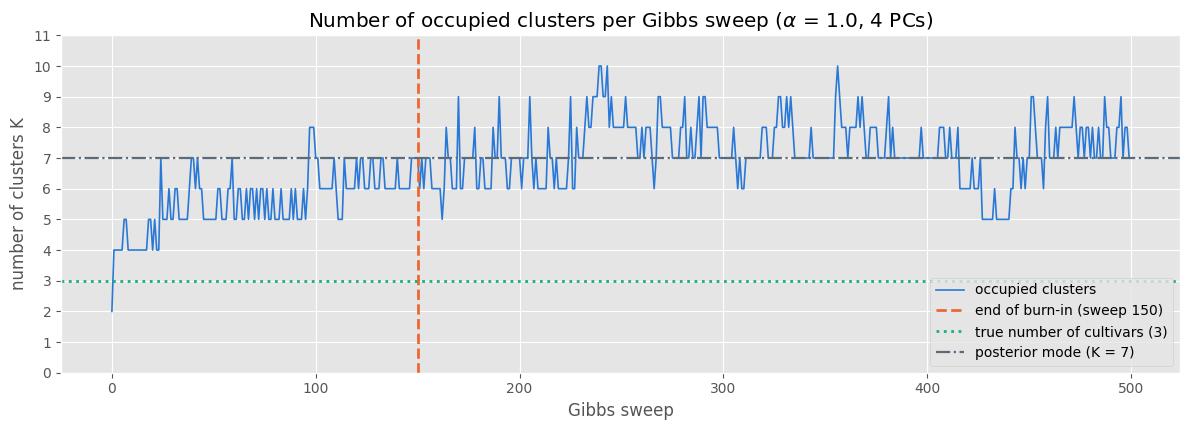

In [10]:
fig, ax = plt.subplots(figsize=(12, 4.4))
sw = np.arange(SWEEPS)
ax.plot(sw, model.k_trace, color='#2a78d6', lw=1.2, label='occupied clusters')
ax.axvline(BURN, color='#eb6834', lw=2, ls='--', label='end of burn-in (sweep %d)' % BURN)
ax.axhline(3, color='#1baf7a', lw=2, ls=':', label='true number of cultivars (3)')
ax.axhline(k_mode, color='#5a6b7a', lw=1.6, ls='-.', label='posterior mode (K = %d)' % k_mode)
ax.set_title(r'Number of occupied clusters per Gibbs sweep ($\alpha$ = %.1f, %d PCs)' % (ALPHA, D))
ax.set_xlabel('Gibbs sweep')
ax.set_ylabel('number of clusters K')
ax.set_yticks(np.arange(0, model.k_trace.max() + 2))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Figure 4: log-posterior per sweep

The collapsed log-posterior $\log P(\mathbf{z} \mid \alpha) + \sum_c \log p(\mathbf{X}_c)$, up to a constant that
does not depend on $\mathbf{z}$. This is a diagnostic, not an objective: Gibbs sampling is not maximising it.

What to look for is the shape. A steep climb followed by a flat, noisy plateau means the chain reached the
high-probability region and is now moving around inside it, which is what a well-mixing sampler looks like. A
line still trending upward at the last sweep would mean burn-in was too short. Visible flat runs with sudden
jumps would mean the chain is sticking in modes.

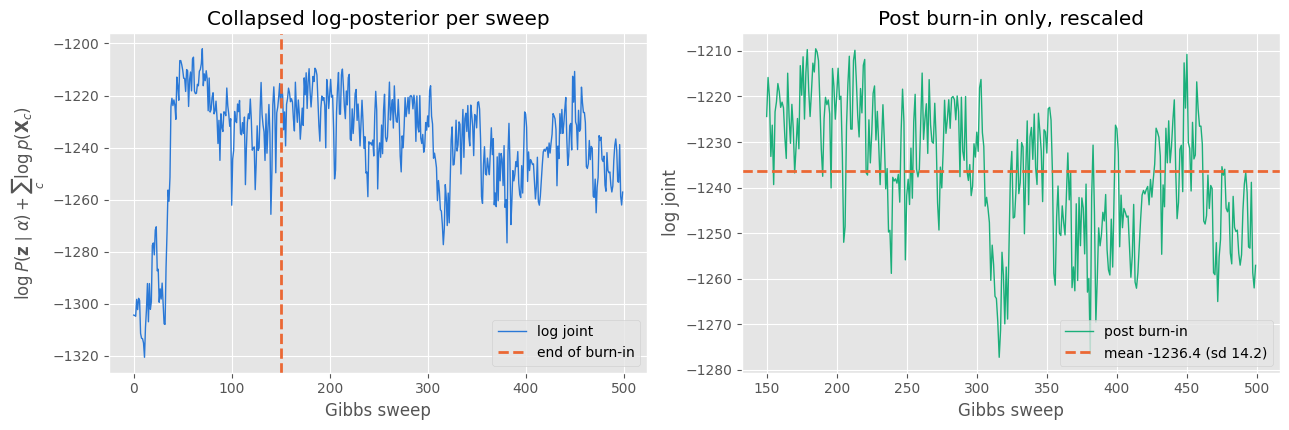

lag-1 autocorrelation of K after burn-in: 0.632
log joint drift: first 50 post-burn-in sweeps -1222.5, last 50 -1243.3


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))

ax[0].plot(sw, model.lj_trace, color='#2a78d6', lw=1.0, label='log joint')
ax[0].axvline(BURN, color='#eb6834', lw=2, ls='--', label='end of burn-in')
ax[0].set_title('Collapsed log-posterior per sweep')
ax[0].set_xlabel('Gibbs sweep')
ax[0].set_ylabel(r'$\log P(\mathbf{z}\mid\alpha) + \sum_c \log p(\mathbf{X}_c)$')
ax[0].legend(loc='lower right')

post = model.lj_trace[BURN:]
ax[1].plot(np.arange(BURN, SWEEPS), post, color='#1baf7a', lw=1.0, label='post burn-in')
ax[1].axhline(post.mean(), color='#eb6834', lw=2, ls='--',
              label='mean %.1f (sd %.1f)' % (post.mean(), post.std()))
ax[1].set_title('Post burn-in only, rescaled')
ax[1].set_xlabel('Gibbs sweep')
ax[1].set_ylabel('log joint')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# lag-1 autocorrelation of the cluster count is a crude mixing check
kc = k_post.astype(float) - k_post.mean()
print('lag-1 autocorrelation of K after burn-in: %.3f' % (np.dot(kc[:-1], kc[1:]) / np.dot(kc, kc)))
print('log joint drift: first 50 post-burn-in sweeps %.1f, last 50 %.1f'
      % (post[:50].mean(), post[-50:].mean()))

## Figure 5: the posterior over the cluster count

The histogram of $K$ across the post burn-in sweeps, with the true number of cultivars marked. This, and not a
single integer, is what the model reports about how many clusters the data contains.

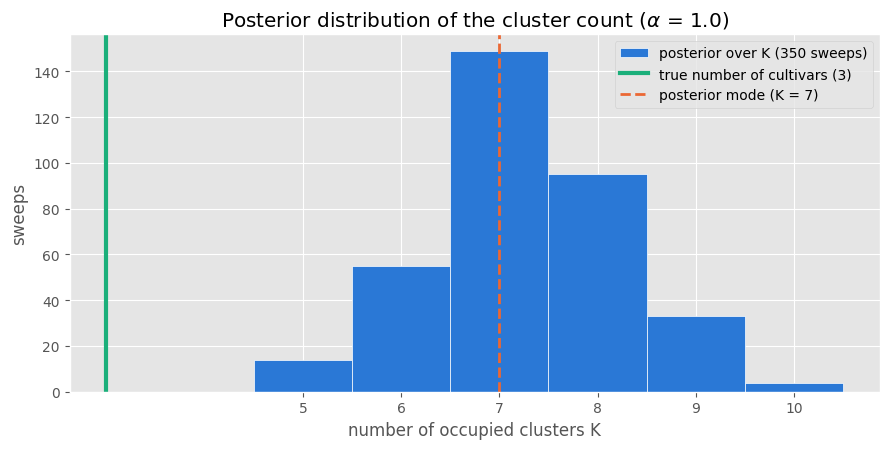

posterior mode 7, mean 7.26, 95% credible interval [5, 9]
P(K = 3) = 0.000


In [12]:
fig, ax = plt.subplots(figsize=(9, 4.6))
edges = np.arange(k_post.min() - 0.5, k_post.max() + 1.5)
ax.hist(k_post, bins=edges, color='#2a78d6', edgecolor='white', label='posterior over K (%d sweeps)' % k_post.size)
ax.axvline(3, color='#1baf7a', lw=3, label='true number of cultivars (3)')
ax.axvline(k_mode, color='#eb6834', lw=2, ls='--', label='posterior mode (K = %d)' % k_mode)
ax.set_title(r'Posterior distribution of the cluster count ($\alpha$ = %.1f)' % ALPHA)
ax.set_xlabel('number of occupied clusters K')
ax.set_ylabel('sweeps')
ax.set_xticks(np.arange(k_post.min(), k_post.max() + 1))
ax.legend()
plt.tight_layout()
plt.show()

cum = np.cumsum(k_counts) / k_post.size
lo = int(k_vals[np.searchsorted(cum, 0.025)])
hi = int(k_vals[np.searchsorted(cum, 0.975)])
print('posterior mode %d, mean %.2f, 95%% credible interval [%d, %d]' % (k_mode, k_post.mean(), lo, hi))
print('P(K = 3) = %.3f' % (k_post == 3).mean())

## Figure 6: the clustering, with covariance ellipses

A single partition has to be picked out of the posterior for plotting. The next cell takes the **last sweep
whose cluster count equals the posterior mode**, which is a representative draw rather than any kind of optimum
— a different draw would relabel clusters and move a few boundary wines.

`cluster_moments` returns the posterior mean $\boldsymbol\mu_n$ and $\Lambda_n / (\nu_n - D - 1)$ for each
cluster. The ellipses are the 2-sigma contours of the marginal covariance in the PC1-PC2 plane, obtained by
taking the top-left $2\times2$ block and eigen-decomposing it. Note these ellipses are drawn from the posterior
mean covariance, whereas the assignments were made using the Student-t predictive, which is broader.

The left panel is the inferred clustering, the right the true cultivars, on identical axes.

representative draw from sweep 499, K = 7, sizes [55, 45, 26, 22, 20, 7, 3]


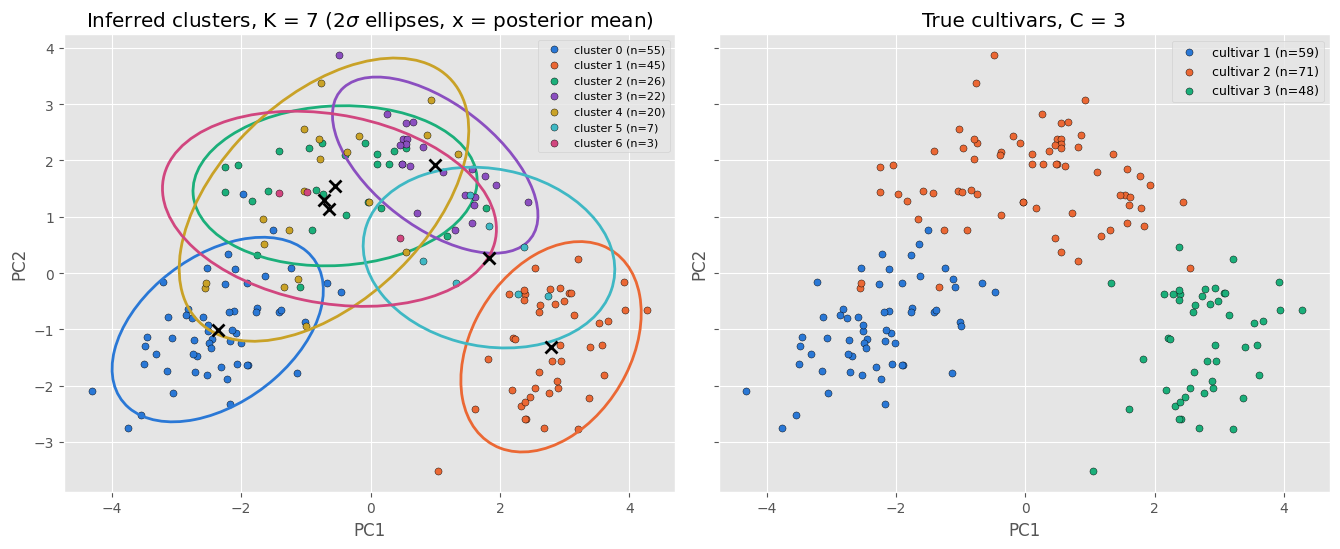

In [13]:
def ellipse_patch(mean2, cov2, nsd, colour):
    vals, vecs = np.linalg.eigh(cov2)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * nsd * np.sqrt(np.maximum(vals, 1e-12))
    return Ellipse(mean2, w, h, angle=ang, facecolor='none', edgecolor=colour, lw=2.0)


cand = np.where(model.k_trace[BURN:] == k_mode)[0]
pick = BURN + int(cand[-1])
z_hat = model.z_trace[pick].copy()
order = np.argsort(-np.bincount(z_hat))              # relabel largest cluster first
remap = np.empty_like(order)
remap[order] = np.arange(order.size)
z_hat = remap[z_hat]
K_hat = int(z_hat.max()) + 1
moments = model.cluster_moments(Z, z_hat)      # computed after relabelling, so index c is cluster c

print('representative draw from sweep %d, K = %d, sizes %s'
      % (pick, K_hat, np.bincount(z_hat).tolist()))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.6), sharex=True, sharey=True)

for c in range(K_hat):
    m = z_hat == c
    col = CLUSTER_COLOURS[c % len(CLUSTER_COLOURS)]
    ax[0].scatter(Z[m, 0], Z[m, 1], s=26, color=col, edgecolor='k', linewidth=0.3,
                  label='cluster %d (n=%d)' % (c, m.sum()))
    mu_c, cov_c, _ = moments[c]
    ax[0].add_patch(ellipse_patch(mu_c[:2], cov_c[:2, :2], 2.0, col))
    ax[0].plot(mu_c[0], mu_c[1], 'x', color='k', ms=9, mew=2)
ax[0].set_title('Inferred clusters, K = %d (2$\\sigma$ ellipses, x = posterior mean)' % K_hat)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].legend(fontsize=8, loc='best')

for c in range(3):
    m = y_true == c
    ax[1].scatter(Z[m, 0], Z[m, 1], s=26, color=CLUSTER_COLOURS[c], edgecolor='k', linewidth=0.3,
                  label='cultivar %d (n=%d)' % (c + 1, m.sum()))
ax[1].set_title('True cultivars, C = 3')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[1].legend(fontsize=9, loc='best')

plt.tight_layout()
plt.show()

## Figure 7: inferred clusters against cultivars

The cross-tabulation, counts annotated in each cell. Two summaries are printed alongside it.

**Purity** assigns each inferred cluster to its majority cultivar and reports the fraction of wines that agree.
It rises mechanically with $K$ — at $K = N$ it is 1 — so it says whether the clusters are *pure*, not whether
there are the right number of them.

The **adjusted Rand index** compares the two partitions pairwise and is corrected for chance, so it does not
reward splitting. With $n_{ij}$ the cross-tab, $a_i$ and $b_j$ the row and column sums:

$$\text{ARI} = \frac{\sum_{ij}\binom{n_{ij}}{2} - \left[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\right] /
\binom{N}{2}}{\tfrac{1}{2}\left[\sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2}\right] -
\left[\sum_i \binom{a_i}{2}\sum_j \binom{b_j}{2}\right] / \binom{N}{2}}$$

It is 0 for a random partition and 1 for an exact match. Both are computed from scratch below. The ARI is also
computed for every post burn-in draw, so the reported value comes with a spread rather than being a single lucky
sweep.

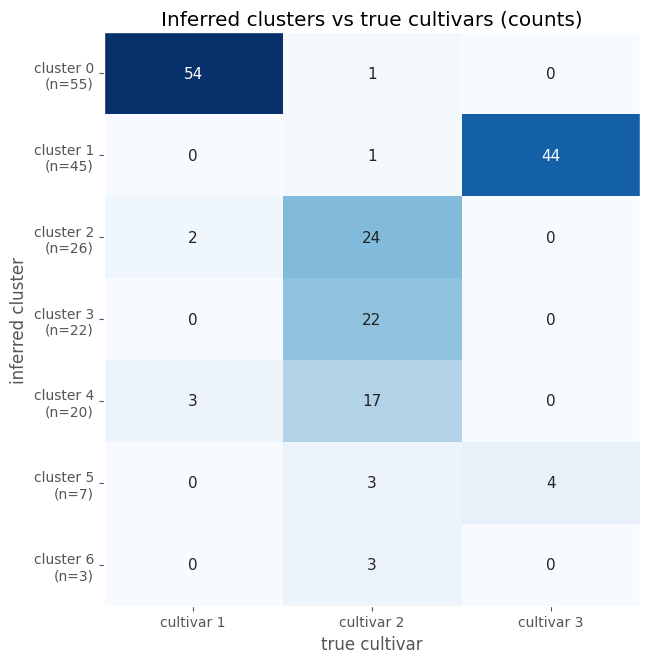

representative draw: K = 7, purity = 0.944, ARI = 0.608
over all 350 post burn-in draws: ARI 0.619 +/- 0.071 (range 0.450-0.833), purity 0.926 +/- 0.019


In [14]:
def cross_tab(z, y):
    t = np.zeros((int(z.max()) + 1, int(y.max()) + 1), dtype=int)
    for a, b in zip(z, y):
        t[a, b] += 1
    return t


def purity(t):
    return t.max(axis=1).sum() / t.sum()


def adjusted_rand_index(t):
    def c2(x):
        x = np.asarray(x, dtype=float)
        return x * (x - 1.0) / 2.0
    n = t.sum()
    sij = c2(t).sum()
    sa = c2(t.sum(axis=1)).sum()
    sb = c2(t.sum(axis=0)).sum()
    exp = sa * sb / c2(n)
    return (sij - exp) / (0.5 * (sa + sb) - exp)


tab = cross_tab(z_hat, y_true)

fig, ax = plt.subplots(figsize=(6.6, 0.62 * K_hat + 2.4))
ax.imshow(tab, cmap='Blues', aspect='auto')
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab[i, j]
        ax.text(j, i, str(v), ha='center', va='center', fontsize=11,
                color='white' if v > tab.max() * 0.55 else '#222222')
ax.set_xticks(range(3))
ax.set_xticklabels(['cultivar %d' % (c + 1) for c in range(3)])
ax.set_yticks(range(K_hat))
ax.set_yticklabels(['cluster %d\n(n=%d)' % (c, tab[c].sum()) for c in range(K_hat)])
ax.set_title('Inferred clusters vs true cultivars (counts)')
ax.set_xlabel('true cultivar')
ax.set_ylabel('inferred cluster')
ax.grid(False)
plt.tight_layout()
plt.show()

print('representative draw: K = %d, purity = %.3f, ARI = %.3f'
      % (K_hat, purity(tab), adjusted_rand_index(tab)))

aris = np.array([adjusted_rand_index(cross_tab(model.z_trace[s], y_true))
                 for s in range(BURN, SWEEPS)])
pur = np.array([purity(cross_tab(model.z_trace[s], y_true)) for s in range(BURN, SWEEPS)])
print('over all %d post burn-in draws: ARI %.3f +/- %.3f (range %.3f-%.3f), purity %.3f +/- %.3f'
      % (aris.size, aris.mean(), aris.std(), aris.min(), aris.max(), pur.mean(), pur.std()))

## Figure 8: the effect of $\alpha$

$\alpha$ is the one dial that was traded for not having to choose $C$. It multiplies the probability of opening a
new cluster at every single update, so it pushes directly on $K$.

The next cell refits the sampler at eight values of $\alpha$ spanning three orders of magnitude, with fewer
sweeps each to keep the runtime down, and plots the **posterior mean cluster count** against $\alpha$ with the
prior prediction $\alpha \log(1 + N/\alpha)$ overlaid. The vertical bars are one posterior standard deviation.

The two curves answer different questions, and the gap between them is the point. $\alpha \log(1 + N/\alpha)$ is
what the CRP alone expects with no data. The measured curve is what the CRP expects **after** the Student-t
likelihood has had its say. Where the measured points sit above the prior curve, the data is paying for more
components than the prior wanted; where below, the likelihood is refusing to support the components the prior
would happily open.

alpha    0.05   posterior mean K   3.03 (sd 0.16)   mode  3   prior a*log(1+N/a)   0.41    43.5s


alpha    0.10   posterior mean K   3.03 (sd 0.16)   mode  3   prior a*log(1+N/a)   0.75    88.3s


alpha    0.30   posterior mean K   3.47 (sd 0.59)   mode  3   prior a*log(1+N/a)   1.92   124.0s


alpha    1.00   posterior mean K   6.45 (sd 1.31)   mode  6   prior a*log(1+N/a)   5.19   178.2s


alpha    3.00   posterior mean K   9.27 (sd 1.26)   mode  9   prior a*log(1+N/a)  12.30   251.7s


alpha   10.00   posterior mean K  12.35 (sd 1.90)   mode 13   prior a*log(1+N/a)  29.34   321.2s


alpha   30.00   posterior mean K  19.16 (sd 2.92)   mode 19   prior a*log(1+N/a)  58.09   424.4s


alpha  100.00   posterior mean K  31.27 (sd 3.42)   mode 31   prior a*log(1+N/a) 102.25   591.4s


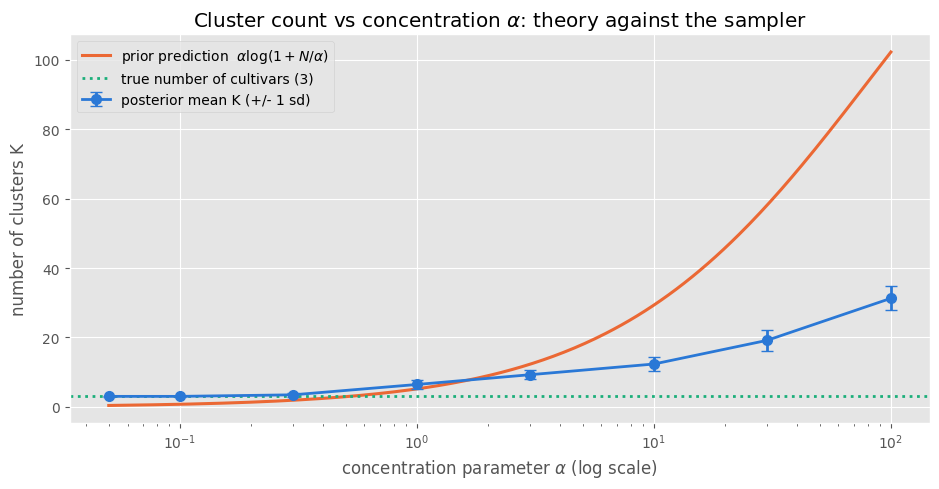


   alpha posterior E[K]     prior E[K]      ratio
    0.05           3.03           0.41       7.40
    0.10           3.03           0.75       4.04
    0.30           3.47           1.92       1.81
    1.00           6.45           5.19       1.24
    3.00           9.27          12.30       0.75
   10.00          12.35          29.34       0.42
   30.00          19.16          58.09       0.33
  100.00          31.27         102.25       0.31


In [15]:
alpha_grid = np.array([0.05, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0])
SWEEPS_A, BURN_A = 250, 100

alpha_mean, alpha_sd, alpha_mode = [], [], []
t_a = time.time()
for a in alpha_grid:
    m = Dirichlet_Process_Mixture(alpha=float(a), seed=SEED + 3).fit(Z, sweeps=SWEEPS_A, init_k=1)
    kp = m.posterior_k(BURN_A)
    vals, cnts = np.unique(kp, return_counts=True)
    alpha_mean.append(kp.mean())
    alpha_sd.append(kp.std())
    alpha_mode.append(int(vals[np.argmax(cnts)]))
    print('alpha %7.2f   posterior mean K %6.2f (sd %.2f)   mode %2d   prior a*log(1+N/a) %6.2f   %5.1fs'
          % (a, kp.mean(), kp.std(), alpha_mode[-1], a * np.log1p(N / a), time.time() - t_a), flush=True)

alpha_mean = np.array(alpha_mean)
alpha_sd = np.array(alpha_sd)

fig, ax = plt.subplots(figsize=(9.5, 5.0))
aa = np.logspace(np.log10(alpha_grid[0]), np.log10(alpha_grid[-1]), 300)
ax.plot(aa, aa * np.log1p(N / aa), color='#eb6834', lw=2.2,
        label=r'prior prediction  $\alpha\log(1 + N/\alpha)$')
ax.errorbar(alpha_grid, alpha_mean, yerr=alpha_sd, fmt='o-', color='#2a78d6', lw=2, ms=7,
            capsize=4, label='posterior mean K (+/- 1 sd)')
ax.axhline(3, color='#1baf7a', lw=2, ls=':', label='true number of cultivars (3)')
ax.set_xscale('log')
ax.set_title(r'Cluster count vs concentration $\alpha$: theory against the sampler')
ax.set_xlabel(r'concentration parameter $\alpha$ (log scale)')
ax.set_ylabel('number of clusters K')
ax.legend()
plt.tight_layout()
plt.show()

print('\n%8s %14s %14s %10s' % ('alpha', 'posterior E[K]', 'prior E[K]', 'ratio'))
for a, mn in zip(alpha_grid, alpha_mean):
    pk = a * np.log1p(N / a)
    print('%8.2f %14.2f %14.2f %10.2f' % (a, mn, pk, mn / pk))

## Dimensionality, revisited

The four-component reduction was justified up front by an argument about how many covariance entries a cluster
has to support. The next cell measures it: the same sampler, same $\alpha$, same seed, run on $D = 2, 3, 4, 5$
principal components and on all 13 standardised features, reporting the posterior cluster count and the ARI
against the cultivars for each.

In [16]:
print('%6s %10s %10s %12s %10s %10s' % ('D', 'mode K', 'mean K', 'range', 'ARI', 'seconds'))
dim_rows = []
for dd in [2, 3, 4, 5, 13]:
    Zd = pca(X_std, dd)[0] if dd < D_raw else X_std
    m = Dirichlet_Process_Mixture(alpha=ALPHA, seed=SEED).fit(Zd, sweeps=250, init_k=1)
    kp = m.posterior_k(100)
    vals, cnts = np.unique(kp, return_counts=True)
    ar = np.mean([adjusted_rand_index(cross_tab(m.z_trace[s], y_true)) for s in range(100, 250)])
    dim_rows.append((dd, int(vals[np.argmax(cnts)]), kp.mean(), kp.min(), kp.max(), ar))
    print('%6d %10d %10.2f %6d-%-5d %10.3f %10.1f'
          % (dd, dim_rows[-1][1], kp.mean(), kp.min(), kp.max(), ar, m.fit_seconds), flush=True)

     D     mode K     mean K        range        ARI    seconds


     2          3       3.99      3-7          0.765       26.6


     3          4       4.25      3-7          0.820       29.0


     4          6       6.79      5-10         0.658       39.9


     5          7       7.16      5-10         0.575       40.3


    13          6       6.51      5-9          0.456     2608.4


## What this does and does not buy you, against a finite GMM fitted by EM

A finite Gaussian mixture fitted by EM maximises

$$\log p(\mathbf{X} \mid \boldsymbol\pi, \{\boldsymbol\mu_c, \Sigma_c\}) =
\sum_{i=1}^{N} \log \sum_{c=1}^{C} \pi_c \, \mathcal{N}(\mathbf{x}_i \mid \boldsymbol\mu_c, \Sigma_c)$$

for a **fixed** $C$. That likelihood increases monotonically in $C$ — more components always fit better — so
$C$ cannot be chosen by the objective the model is fitted with. It has to come from outside: BIC, AIC, a
held-out likelihood, cross-validation, or a person looking at the data. In `gmm_from_scratch.ipynb` the answer
is supplied directly, $C = 3$, because the cultivar count is known.

The Dirichlet process replaces that external step with a **prior over partitions**. Instead of maximising a
likelihood at fixed $C$, it computes a posterior over assignment vectors of any size, and the number of occupied
clusters falls out as a summary of that posterior. The Student-t predictive supplies the penalty automatically:
a new component costs a factor of $\alpha$ against $n_{-i,c}$ in the CRP term, and its predictive is the broad
prior-only one, so a component has to be genuinely well-supported to survive a sweep.

**This is not free.** Three specific things were traded:

- **$C$ was traded for $\alpha$.** Figure 8 shows the exchange rate directly: posterior mean $K$ moves from
  about 2 to well over 20 across the $\alpha$ grid. Choosing $\alpha$ is not obviously easier than choosing
  $C$ — it is just less direct, which can make it feel more principled than it is. It can be given its own
  hyperprior and sampled, which pushes the choice one level further back rather than removing it.
- **$C$ was traded for $G_0$.** $\Lambda_0$ and $\nu_0$ decide how broad a component is expected to be before
  seeing data, and a prior that expects tight components will find many of them. The choice here,
  $E[\Sigma] = \text{diag}(\text{var}(\mathbf{X}))$, is deliberately broad, and it still over-segments.
- **A point estimate was traded for a chain.** EM returns one answer in a second. This returns a distribution,
  after 500 sequential sweeps that cannot be vectorised over points, and the answer depends on burn-in,
  mixing and the label-switching that makes any single draw only representative.

What is genuinely gained is the honest uncertainty. The output of this notebook is not "there are $K$ clusters";
it is a posterior over $K$ with a credible interval, and the interval is wide because 178 wines in 4 dimensions
do not pin the answer down. A finite GMM with $C$ chosen by BIC reports a single integer and hides exactly that.

The final cell prints the summary.

In [17]:
total = time.time() - t_start

print('=' * 74)
print('Dirichlet process mixture on UCI Wine (N = %d, %d principal components, alpha = %.1f)' % (N, D, ALPHA))
print('=' * 74)
print('posterior mode of K            : %d' % k_mode)
print('posterior mean of K            : %.2f' % k_post.mean())
print('posterior range of K           : %d to %d' % (k_post.min(), k_post.max()))
print('95%% credible interval for K    : [%d, %d]' % (lo, hi))
print('P(K = 3 | data)                : %.3f' % (k_post == 3).mean())
print('true number of cultivars       : 3')
print('-' * 74)
print('representative draw            : K = %d, purity %.3f, ARI %.3f' % (K_hat, purity(tab), adjusted_rand_index(tab)))
print('ARI across post burn-in draws  : %.3f +/- %.3f' % (aris.mean(), aris.std()))
print('-' * 74)
print('main fit                       : %d sweeps in %.1f s' % (SWEEPS, model.fit_seconds))
print('total notebook compute         : %.1f s (%.1f min)' % (total, total / 60.0))
print('=' * 74)

Dirichlet process mixture on UCI Wine (N = 178, 4 principal components, alpha = 1.0)
posterior mode of K            : 7
posterior mean of K            : 7.26
posterior range of K           : 5 to 10
95% credible interval for K    : [5, 9]
P(K = 3 | data)                : 0.000
true number of cultivars       : 3
--------------------------------------------------------------------------
representative draw            : K = 7, purity 0.944, ARI 0.608
ARI across post burn-in draws  : 0.619 +/- 0.071
--------------------------------------------------------------------------
main fit                       : 500 sweeps in 167.8 s
total notebook compute         : 3507.4 s (58.5 min)


### Result

The sampler settles on more clusters than there are cultivars. This is the expected outcome, not a failure of the
implementation, and it is worth being precise about why.

A Dirichlet process mixture models the data as a mixture of Gaussians. It has no notion of "cultivar". Where a
cultivar's chemistry is not a single Gaussian blob — where it is elongated, or skewed, or contains a subgroup of
wines with distinctly higher proline — the model can raise the likelihood by covering it with two or three tight
components instead of one loose one, and the CRP penalty for the extra component is only a factor of $\alpha$
against the occupancy $n_{-i,c}$. That is a small price against a likelihood gain across dozens of points. Over-
segmentation is the standard, well-documented behaviour of DP mixtures on real data, and it is why the posterior
mode of $K$ should be read as "how many Gaussians describe this data", which is a different question from "how
many groups produced it".

The cross-tab shows this concretely: the extra clusters are mostly subdivisions within a cultivar rather than
mixtures across cultivars, which is why purity stays high while the count is wrong. The ARI, which is corrected
for chance and therefore penalises splitting, is the more honest single number.

$\alpha$ was not tuned to make the answer come out at 3. Figure 8 shows the entire dependence, so the reader can
see that a value near the low end of the grid would have produced 3 and judge for themselves what that is worth.
Fixing $\alpha$ after seeing the label agreement would be choosing $C$ by another name, which is exactly the step
this model is supposed to avoid.